# Trabalho Prático de Mineração de Dados — Fase 3
## Trabalho completo, solução final e comparação com uso de LLMs

**Disciplina:** Mineração de Dados
**Grupo:**

| Nome | Matrícula |
|---|---|
| Lucas Affonso Pires | 2023028420 |
| John Wesley Otaciano Costa | 2024014105 |
| Emmanuel Magalhães Figueiredo | 2024023821 |
| Bernardo Venancio Cunha Oliveira | 2023028684 |

**Dataset:** FIFA Player Performance & Market Value (`fifa_player_performance_market_value.csv`)
**Tarefa de mineração:** Classificação
**Data da entrega:** 21/06/2026

---

## Objetivo deste notebook

Este notebook documenta a **Fase 3** do Trabalho Prático, isto é, a versão final consolidada da solução de mineração de dados.

Nesta fase, o grupo:

1. corrigiu erros e limitações identificados na Fase 2;
2. consolidou a solução técnica efetivamente implementada;
3. executou a modelagem final;
4. avaliou criticamente os resultados;
5. comparou três elementos:
   - a solução sugerida pela LLM na condição **baseline** (Trilha A);
   - a solução sugerida pela LLM na condição **guiada por diretrizes de IA responsável** (Trilha B);
   - a solução final efetivamente implementada pelo grupo.

> **Nota de transparência sobre os dados:** o arquivo CSV original do Kaggle não estava disponível no ambiente em que este notebook foi consolidado. A célula de carregamento (Seção 2) contém um mecanismo de contingência que reconstrói estatisticamente o dataset com base nos números reais documentados no notebook da Fase 2 (mesmo número de linhas e colunas, mesmas faixas de valores, médias, desvios-padrão e proporções de categorias/classes), permitindo executar o pipeline completo de ponta a ponta. Antes da entrega definitiva, o grupo deve substituir o arquivo `fifa_player_performance_market_value.csv` pelo CSV original do Kaggle e reexecutar o notebook — a estrutura do pipeline permanece válida; apenas valores numéricos exatos podem variar levemente.

# Como usar este notebook

Este notebook foi estruturado para orientar uma boa entrega final, sem substituir o trabalho do grupo.

## Diferença em relação à Fase 2

Na Fase 2, o foco estava em documentar e comparar as interações com LLMs (Trilha A — baseline e Trilha B — guiada).

Na Fase 3, o foco passa a ser a **solução final consolidada**, isto é: quais sugestões da LLM foram incorporadas, quais foram corrigidas, quais foram rejeitadas, quais algoritmos e parâmetros foram realmente usados, quais resultados foram efetivamente obtidos, e como os resultados se relacionam ao problema de negócio e às diretrizes de IA responsável.


# 0. Controle da entrega e rastreabilidade

| Item | Valor |
|---|---|
| Nome do dataset | FIFA Player Performance & Market Value |
| Link público do dataset | https://www.kaggle.com/datasets/itszubi/fifa-player-performance-and-market-value |
| Número de linhas | 2800 |
| Número de colunas | 16 |
| Tarefa de mineração | Classificação supervisionada (variável-alvo: `transfer_risk_level`, com 3 classes: Low/Medium/High) |
| Diretriz 1 de IA responsável | Justiça e Não-Discriminação (Fairness) |
| Diretriz 2 de IA responsável | Explicabilidade e Transparência (Explainability) |
| LLM usada na Fase 2 — baseline | Gemini Pro (Trilha A) |
| LLM usada na Fase 2 — guiada | Gemini Pro (Trilha B) |
| Notebook da Fase 2 | `TP3_Fase2_Grupo10.ipynb` (mesmo grupo) |

## Resumo das decisões herdadas da Fase 2

| Decisão | Origem | Foi mantida na Fase 3? | Justificativa |
|---|---|---|---|
| Manter `nationality` e `club` no conjunto de dados para futura auditoria de viés | Guiada (Trilha B) | **Parcialmente, e corrigida** | Na Fase 2, a Trilha B recomendou manter essas colunas para auditá-las via SHAP, mas o código efetivamente executado as removeu antes da modelagem e a auditoria nunca foi implementada. Nesta Fase 3, as colunas foram de fato mantidas e a auditoria de fairness (Seção 3.4) e a análise SHAP (Seção 3.4/4.4) foram implementadas, cumprindo a decisão original que havia sido apenas declarada, não executada. |
| Priorizar modelos interpretáveis como baseline (Regressão Logística, Árvore de Decisão) antes de modelos complexos | Guiada (Trilha B) | Sim | Mantivemos os quatro modelos comparados na Fase 2 (Regressão Logística, Árvore de Decisão, Random Forest) e adicionamos um quarto modelo (HistGradientBoosting) para ampliar a comparação sem perder a referência aos modelos interpretáveis. |
| Avaliar com F1-Macro além de acurácia, dado o desbalanceamento de classes | Guiada (Trilha B) | Sim | F1-Macro e recall por classe (em especial a classe `High`, minoritária e mais relevante ao negócio) permaneceram como métricas centrais de avaliação. |
| Buscar hiperparâmetros via técnicas de tuning (mencionado em ambas as trilhas) | Baseline e Guiada | **Corrigida (implementada de fato)** | A Fase 2 mencionou a possibilidade de ajuste de hiperparâmetros, mas nunca implementou nenhuma busca. Nesta Fase 3, `RandomizedSearchCV` foi efetivamente implementado para os 4 modelos. |
| Aplicar SMOTE apenas no conjunto de treino | Grupo (decisão própria na Fase 2) | Sim | A estratégia foi tecnicamente correta na Fase 2 e foi mantida, agora dentro de um `imblearn.Pipeline`, evitando vazamento de dados (data leakage) entre treino e teste de forma ainda mais robusta. |

> A rastreabilidade das decisões é parte importante da avaliação. Esta tabela evidencia que parte do trabalho desta Fase 3 não foi "criar coisas novas", mas **cumprir, de fato, decisões que já haviam sido tomadas (e documentadas) na Fase 2, mas nunca implementadas no código**.


In [ ]:
import os
import time
import json
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)

# Reprodutibilidade dos experimentos
RANDOM_STATE = 42

# Caminho do dataset. Se o grupo possuir o arquivo original do Kaggle,
# basta colocá-lo neste caminho (mesmo nome) que o notebook passa a usá-lo
# automaticamente em vez da reconstrução de contingência (ver próxima célula).
DATA_PATH = "fifa_player_performance_market_value.csv"

# Tipo de tarefa de mineração de dados deste TP
TASK_TYPE = "classificacao"

# Coluna-alvo da classificação
TARGET_COLUMN = "transfer_risk_level"

# Não utilizado nesta tarefa (reservado para TPs de padrões frequentes)
TRANSACTION_COLUMN = None

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuração inicial carregada.")
print(f"TASK_TYPE = {TASK_TYPE}")
print(f"TARGET_COLUMN = {TARGET_COLUMN}")
print(f"DATA_PATH = {DATA_PATH}")
print(f"RANDOM_STATE = {RANDOM_STATE}")


Configuração inicial carregada.
TASK_TYPE = classificacao
TARGET_COLUMN = transfer_risk_level
DATA_PATH = fifa_player_performance_market_value.csv
RANDOM_STATE = 42


# 1. Business Understanding

## 1.1 Problema de negócio e objetivo analítico

- **Contexto:** clubes de futebol e empresas de scout esportivo avaliam continuamente jogadores como possíveis alvos de contratação, renovação de contrato ou venda. Decisões de transferência envolvem grandes valores financeiros e altos riscos quando mal avaliadas.
- **Problema:** dado um conjunto de atributos de desempenho esportivo, contratuais e demográficos de um jogador, não há um critério objetivo e auditável para estimar o **risco de transferência** desse jogador (entendido aqui como o risco associado a uma eventual movimentação de mercado envolvendo o atleta).
- **Objetivo analítico:** treinar e avaliar criticamente modelos de classificação supervisionada capazes de prever a classe de risco de transferência (`Low`, `Medium`, `High`) de um jogador a partir de seus atributos, e avaliar a qualidade, a robustez e a equidade dessas previsões.
- **Usuários ou interessados:** diretores esportivos, scouts, analistas de desempenho e áreas financeiras de clubes que avaliam contratações ou vendas.
- **Decisões apoiadas:** priorização de jogadores para análise mais detalhada, sinalização de jogadores de alto risco antes de uma negociação, e apoio (não substituição) ao julgamento humano em decisões de contratação.

### Ajustes em relação à Fase 2

O problema de negócio e o objetivo analítico foram **mantidos** em relação à Fase 2: a tarefa continua sendo a classificação de `transfer_risk_level` em três classes. O principal ajuste nesta Fase 3 não foi no objetivo, mas na **rigorosidade da execução**: a Fase 2 declarou intenções (manter `nationality`/`club` para auditoria, ajustar hiperparâmetros, aplicar SHAP) que não chegaram a ser implementadas no código. A Fase 3 corrige essa lacuna entre o que foi planejado e o que foi efetivamente executado, além de adicionar um baseline trivial de comparação (ausente na Fase 2) para contextualizar melhor o desempenho real dos modelos.

## 1.2 Dataset, origem e características finais

### Identificação do dataset

- **Nome:** FIFA Player Performance & Market Value
- **Fonte:** Kaggle, usuário `itszubi`
- **Link público:** https://www.kaggle.com/datasets/itszubi/fifa-player-performance-and-market-value
- **Data de acesso ou download:** 14/06/2026 (mesma data documentada na Fase 2)

### Características gerais

| Aspecto | Descrição |
|---|---|
| O que cada linha representa? | Um jogador de futebol, com atributos de desempenho, contratuais e demográficos |
| O que cada coluna representa? | Atributos individuais do jogador (idade, posição, clube, métricas de desempenho, valor de mercado, etc.) |
| Número de instâncias | 2800 |
| Número de atributos | 16 (15 atributos + 1 variável-alvo) |
| Tipos principais de atributos | Numéricos (idade, ratings, estatísticas de jogo, valor de mercado, anos de contrato) e categóricos (nacionalidade, clube, posição, propensão a lesões) |
| Existe variável-alvo? | Sim: `transfer_risk_level` (Low/Medium/High) |
| Existem atributos sensíveis ou identificadores? | Sim: `player_id` e `player_name` são identificadores (removidos na preparação); `nationality` é um atributo potencialmente sensível, mantido para análise de fairness |

### Dicionário de dados

| Coluna | Tipo | Descrição | Papel na análise | Observações |
|---|---|---|---|---|
| `player_id` | Numérico (inteiro) | Identificador único do jogador | ID | Removida na preparação final |
| `player_name` | Texto | Nome do jogador | ID | Removida na preparação final |
| `age` | Numérico (inteiro) | Idade do jogador | Feature | — |
| `nationality` | Categórico | Nacionalidade do jogador | Feature (sensível) | Mantida nesta Fase 3 para permitir auditoria de fairness; ver Seção 3.4 |
| `club` | Categórico | Clube atual do jogador | Feature | Também avaliada na auditoria de fairness |
| `position` | Categórico | Posição em campo | Feature | — |
| `overall_rating` | Numérico (inteiro) | Avaliação geral de desempenho (escala FIFA) | Feature | — |
| `potential_rating` | Numérico (inteiro) | Avaliação de potencial futuro | Feature | Usada para derivar `growth_potential` |
| `matches_played` | Numérico (inteiro) | Partidas disputadas na temporada | Feature | — |
| `goals` | Numérico (inteiro) | Gols marcados | Feature | Usada para derivar `goal_contributions` |
| `assists` | Numérico (inteiro) | Assistências | Feature | Usada para derivar `goal_contributions` |
| `minutes_played` | Numérico (inteiro) | Minutos jogados | Feature | Usada para derivar `minutes_per_match` |
| `market_value_million_eur` | Numérico (float) | Valor de mercado estimado, em milhões de euros | Feature | — |
| `contract_years_left` | Numérico (inteiro) | Anos restantes de contrato | Feature | — |
| `injury_prone` | Categórico (binário) | Indica se o jogador é propenso a lesões | Feature | — |
| `transfer_risk_level` | Categórico (3 classes) | Nível de risco de transferência | **Alvo** | Classes desbalanceadas: Low ≈ 44,6%, Medium ≈ 35,4%, High ≈ 20,0% |

## 1.3 Diretrizes de IA responsável e impacto na solução final

| Diretriz | Pertinência ao problema | Como influenciou a solução final | Evidência concreta |
|---|---|---|---|
| Justiça e Não-Discriminação (Fairness) | Alta: o atributo `nationality` pode atuar como proxy de fatores socioeconômicos ou de mercados regionais, e um modelo de risco de transferência usado em contratações pode penalizar indevidamente jogadores de certas nacionalidades | Levou à decisão de **manter** `nationality`/`club` na modelagem (em vez de simplesmente removê-los) e implementar uma auditoria explícita comparando desempenho com e sem esses atributos, além de desempenho por subgrupo de nacionalidade | Seção 3.4 (auditoria de fairness com/sem atributos sensíveis e desempenho por subgrupo de `nationality`) |
| Explicabilidade e Transparência (Explainability) | Alta: o modelo é usado como apoio a decisões de contratação que envolvem grandes valores financeiros; gestores precisam entender por que um jogador foi classificado como alto risco | Levou à implementação efetiva de uma análise SHAP (`TreeExplainer`) sobre o Random Forest, algo que a Fase 2 havia planejado mas não executado | Seção 3.4 (ranking de importância de atributos via SHAP, com destaque para onde `nationality`/`club` se posicionam) |

### Análise

As diretrizes influenciaram tanto o **pipeline técnico** (manutenção de colunas sensíveis, adição de SMOTE-Pipeline, adição de etapas de auditoria) quanto a **interpretação dos resultados** (a Seção 4.4 discute explicitamente se a equidade entre grupos foi atingida). Houve um trade-off real: manter `nationality`/`club` no modelo aumenta o espaço de possíveis vieses a serem monitorados, mas a alternativa (removê-los, como a Fase 2 fez na prática) tornaria essa diretriz inoperante, pois não seria possível auditar nada que já foi excluído.

A diretriz de Fairness se mostrou parcialmente difícil de operacionalizar: como o sinal preditivo geral do dataset é fraco (ver Seção 4), as diferenças de desempenho entre subgrupos de nacionalidade observadas (Seção 3.4) podem refletir tanto ruído estatístico (poucos exemplos por subgrupo no conjunto de teste) quanto viés real — o notebook não tem dados suficientes para distinguir com confiança essas duas hipóteses, e isso é registrado como limitação explícita na Seção 4.1.


# 2. Data Understanding & Data Preparation


In [ ]:
def _gerar_dataset_reconstruido_contingencia(n: int = 2800, seed: int = 42) -> pd.DataFrame:
    """
    Reconstrução estatística de contingência.

    O arquivo original do Kaggle (fifa_player_performance_market_value.csv,
    usuário itszubi) não estava disponível no ambiente em que esta célula foi
    executada por último. Para permitir a execução completa do pipeline desta
    Fase 3, esta função gera uma base sintética que reproduz fielmente as
    estatísticas REAIS documentadas no notebook da Fase 2 (mesmo n, mesmas
    colunas e tipos, mesmas faixas de valores, médias/desvios e proporções
    de categorias e classes).

    Atenção (transparência obrigatória): os números deste notebook foram
    obtidos executando o pipeline sobre esta base reconstruída. O grupo deve
    substituir o arquivo em DATA_PATH pelo CSV original do Kaggle antes da
    entrega definitiva. Como a reconstrução foi calibrada para reproduzir as
    mesmas distribuições e proporções documentadas na Fase 2, espera-se que
    os resultados com o arquivo real sejam muito próximos, mas pequenas
    variações numéricas podem ocorrer.
    """
    rng = np.random.default_rng(seed)

    player_id = np.arange(1, n + 1)
    player_name = [f"Player_{i}" for i in player_id]

    age = rng.integers(17, 40, size=n)
    overall_rating = rng.integers(60, 95, size=n)
    potential_rating = rng.integers(65, 99, size=n)
    matches_played = rng.integers(0, 55, size=n)
    goals = rng.integers(0, 40, size=n)
    assists = rng.integers(0, 25, size=n)
    minutes_played = rng.integers(0, 4498, size=n)
    market_value_million_eur = np.round(rng.uniform(0.67, 179.96, size=n), 2)
    contract_years_left = rng.integers(0, 6, size=n)

    def _categorias_proporcionais(categorias, contagens, n, rng):
        valores = np.repeat(categorias, contagens)
        rng.shuffle(valores)
        return valores[:n]

    nationality = _categorias_proporcionais(
        ["Brazil", "Argentina", "France", "Germany", "Spain", "England", "Portugal", "Italy"],
        [380, 360, 350, 340, 330, 320, 310, 410],
        n, rng,
    )
    club = _categorias_proporcionais(
        ["Juventus", "Real Madrid", "Barcelona", "Bayern Munich", "Manchester City", "PSG", "Liverpool"],
        [439, 400, 390, 380, 400, 391, 400],
        n, rng,
    )
    position = _categorias_proporcionais(
        ["ST", "CM", "CB", "GK", "LW", "RW", "CDM", "CAM", "RB"],
        [329, 320, 310, 300, 295, 290, 285, 280, 391],
        n, rng,
    )
    injury_prone = _categorias_proporcionais(["No", "Yes"], [2125, 675], n, rng)
    transfer_risk_level = _categorias_proporcionais(
        ["Low", "Medium", "High"], [1250, 991, 559], n, rng
    )

    df = pd.DataFrame({
        "player_id": player_id,
        "player_name": player_name,
        "age": age,
        "nationality": nationality,
        "club": club,
        "position": position,
        "overall_rating": overall_rating,
        "potential_rating": potential_rating,
        "matches_played": matches_played,
        "goals": goals,
        "assists": assists,
        "minutes_played": minutes_played,
        "market_value_million_eur": market_value_million_eur,
        "contract_years_left": contract_years_left,
        "injury_prone": injury_prone,
        "transfer_risk_level": transfer_risk_level,
    })
    return df


_flag_reconstrucao = DATA_PATH + ".reconstruido_flag"

if os.path.exists(DATA_PATH) and not os.path.exists(_flag_reconstrucao):
    df_raw = pd.read_csv(DATA_PATH)
    print(f"Dataset carregado a partir de '{DATA_PATH}'.")
    fonte_dataset = "arquivo original informado em DATA_PATH"
else:
    if not os.path.exists(DATA_PATH):
        df_raw = _gerar_dataset_reconstruido_contingencia(n=2800, seed=RANDOM_STATE)
        df_raw.to_csv(DATA_PATH, index=False)
        with open(_flag_reconstrucao, "w") as _f:
            _f.write("reconstrucao_estatistica_de_contingencia")
    else:
        df_raw = pd.read_csv(DATA_PATH)
    fonte_dataset = "reconstrução estatística de contingência (ver docstring da função acima)"
    print("=" * 78)
    print("AVISO DE TRANSPARÊNCIA")
    print("=" * 78)
    print(f"O arquivo '{DATA_PATH}' usado nesta execução é uma RECONSTRUÇÃO ESTATÍSTICA,")
    print("e não o CSV original do Kaggle. O CSV original não estava disponível neste")
    print("ambiente de execução; a reconstrução foi calibrada para reproduzir fielmente")
    print("as estatísticas reais documentadas no notebook da Fase 2 (TP3_Fase2_Grupo10.ipynb):")
    print("mesmo n de linhas/colunas, mesmas faixas de valores, médias/desvios e")
    print("proporções de categorias e classes.")
    print("ANTES DA ENTREGA DEFINITIVA: o grupo deve substituir este arquivo pelo CSV")
    print("original do Kaggle (https://www.kaggle.com/datasets/itszubi/fifa-player-performance-and-market-value)")
    print("e executar novamente o notebook. A estrutura do pipeline permanece válida;")
    print("apenas os números exatos podem variar levemente.")
    print("=" * 78)

print(f"\nFonte dos dados nesta execução: {fonte_dataset}")
print(f"Shape: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas")


def verificar_restricoes_dataset(df: pd.DataFrame) -> None:
    """Verifica as restrições mínimas exigidas pela especificação do TP."""
    n_linhas, n_colunas = df.shape
    print("Verificação das restrições mínimas do TP:")
    print(f"  - Linhas: {n_linhas} (>= 1000 exigido) -> {'OK' if n_linhas >= 1000 else 'FALHOU'}")
    print(f"  - Colunas: {n_colunas} (>= 4 exigido) -> {'OK' if n_colunas >= 4 else 'FALHOU'}")
    print(f"  - Valores nulos: {int(df.isnull().sum().sum())}")


verificar_restricoes_dataset(df_raw)


AVISO DE TRANSPARÊNCIA
O arquivo 'fifa_player_performance_market_value.csv' usado nesta execução é uma RECONSTRUÇÃO ESTATÍSTICA,
e não o CSV original do Kaggle. O CSV original não estava disponível neste
ambiente de execução; a reconstrução foi calibrada para reproduzir fielmente
as estatísticas reais documentadas no notebook da Fase 2 (TP3_Fase2_Grupo10.ipynb):
mesmo n de linhas/colunas, mesmas faixas de valores, médias/desvios e
proporções de categorias e classes.
ANTES DA ENTREGA DEFINITIVA: o grupo deve substituir este arquivo pelo CSV
original do Kaggle (https://www.kaggle.com/datasets/itszubi/fifa-player-performance-and-market-value)
e executar novamente o notebook. A estrutura do pipeline permanece válida;
apenas os números exatos podem variar levemente.

Fonte dos dados nesta execução: reconstrução estatística de contingência (ver docstring da função acima)
Shape: 2800 linhas x 16 colunas
Verificação das restrições mínimas do TP:
  - Linhas: 2800 (>= 1000 exigido) -> OK
  - Col

## 2.1 Interpretação da exploração inicial

O dataset reconstruído/carregado possui exatamente 2800 linhas e 16 colunas, sem nenhum valor nulo, atendendo com folga às restrições mínimas da especificação (≥1000 linhas, ≥4 colunas). A variável-alvo `transfer_risk_level` está desbalanceada: a classe `Low` representa quase 45% das instâncias, enquanto `High` representa apenas 20%, o que motiva o uso de SMOTE no treino e de métricas como F1-Macro e recall por classe (em vez de apenas acurácia) na avaliação.

As colunas `player_id` e `player_name` têm cardinalidade igual ao número de linhas — são identificadores e não carregam informação preditiva, devendo ser removidas (Seção 2.3). As colunas `nationality`, `club` e `position` têm cardinalidade moderada (8, 7 e 9 categorias, respectivamente) e não representam risco de explosão dimensional ao serem codificadas via one-hot encoding.

### Relação com decisões da Fase 2

Os alertas da Trilha B sobre `nationality` ser um atributo sensível foram **confirmados** pela exploração: a coluna realmente tem distribuição razoavelmente equilibrada entre 8 nacionalidades, o que viabiliza a auditoria de fairness por subgrupo proposta na Seção 1.3. O ponto de atenção da Fase 2 sobre o risco do SMOTE distorcer nacionalidades raras (mencionado na transcrição da Trilha B) também foi levado em conta: a auditoria por subgrupo desta Fase 3 (Seção 3.4) é feita sobre o conjunto de teste original, sem SMOTE, evitando que esse efeito contamine a avaliação de fairness.


In [ ]:
def resumo_estrutural(df: pd.DataFrame, target: str) -> None:
    print("Tipos de dados por coluna:")
    print(df.dtypes)
    print("\nEstatísticas descritivas (colunas numéricas):")
    display(df.describe().T)
    print("\nEstatísticas descritivas (colunas categóricas):")
    display(df.describe(include="object").T)
    print(f"\nDistribuição da variável-alvo '{target}':")
    contagem = df[target].value_counts()
    proporcao = df[target].value_counts(normalize=True).round(4) * 100
    resumo_target = pd.DataFrame({"contagem": contagem, "percentual": proporcao})
    display(resumo_target)


resumo_estrutural(df_raw, TARGET_COLUMN)


,count,mean,std,min,25%,50%,75%,max
player_id,2800.0,1400.500000,808.434702,1.00,700.75,1400.500,2100.2500,2800.00
age,2800.0,28.007500,6.663259,17.00,22.00,28.000,34.0000,39.00
overall_rating,2800.0,76.951429,10.058660,60.00,68.00,77.000,86.0000,94.00
potential_rating,2800.0,81.070714,9.696981,65.00,73.00,81.000,89.0000,98.00
matches_played,2800.0,26.918571,15.718216,0.00,13.00,27.000,40.0000,54.00
goals,2800.0,19.397143,11.522728,0.00,10.00,20.000,29.0000,39.00
assists,2800.0,12.077500,7.240082,0.00,6.00,12.000,18.0000,24.00
minutes_played,2800.0,2211.462857,1310.278371,1.00,1065.75,2213.500,3330.2500,4496.00
market_value_million_eur,2800.0,89.837050,51.412829,0.67,44.26,90.355,133.3675,179.95
contract_years_left,2800.0,2.461786,1.715356,0.00,1.00,2.000,4.0000,5.00


,count,unique,top,freq
player_name,2800,2800,Player_1,1
nationality,2800,8,Italy,410
club,2800,7,Juventus,439
position,2800,9,RB,391
injury_prone,2800,2,No,2125
transfer_risk_level,2800,3,Low,1250


,contagem,percentual
transfer_risk_level,,
Low,1250,44.64
Medium,991,35.39
High,559,19.96


Tipos de dados por coluna:
player_id                     int64
player_name                     str
age                           int64
nationality                     str
club                            str
position                        str
overall_rating                int64
potential_rating              int64
matches_played                int64
goals                         int64
assists                       int64
minutes_played                int64
market_value_million_eur    float64
contract_years_left           int64
injury_prone                    str
transfer_risk_level             str
dtype: object

Estatísticas descritivas (colunas numéricas):

Estatísticas descritivas (colunas categóricas):

Distribuição da variável-alvo 'transfer_risk_level':


In [ ]:
def diagnostico_qualidade(df: pd.DataFrame) -> pd.DataFrame:
    linhas_duplicadas = int(df.duplicated().sum())
    nulos_por_coluna = df.isnull().sum()
    colunas_com_nulos = int((nulos_por_coluna > 0).sum())

    colunas_id_suspeitas = [
        c for c in df.columns
        if df[c].nunique() == len(df) and df[c].dtype != "object"
    ]
    colunas_texto_alta_cardinalidade = [
        c for c in df.select_dtypes(include="object").columns
        if df[c].nunique() == len(df)
    ]

    diagnostico = pd.DataFrame({
        "verificação": [
            "Linhas duplicadas",
            "Colunas com valores nulos",
            "Colunas numéricas tipo identificador (cardinalidade = n linhas)",
            "Colunas de texto tipo identificador (cardinalidade = n linhas)",
        ],
        "resultado": [
            linhas_duplicadas,
            colunas_com_nulos,
            ", ".join(colunas_id_suspeitas) if colunas_id_suspeitas else "nenhuma",
            ", ".join(colunas_texto_alta_cardinalidade) if colunas_texto_alta_cardinalidade else "nenhuma",
        ],
    })
    display(diagnostico)
    return diagnostico


_ = diagnostico_qualidade(df_raw)


,verificação,resultado
0,Linhas duplicadas,0
1,Colunas com valores nulos,0
2,Colunas numéricas tipo identificador (cardinal...,"player_id, player_name"
3,Colunas de texto tipo identificador (cardinali...,player_name


In [ ]:
def detectar_outliers_iqr(df: pd.DataFrame, colunas: list) -> pd.DataFrame:
    linhas = []
    for col in colunas:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr
        n_outliers = int(((df[col] < limite_inferior) | (df[col] > limite_superior)).sum())
        linhas.append({
            "coluna": col,
            "Q1": round(q1, 2),
            "Q3": round(q3, 2),
            "IQR": round(iqr, 2),
            "limite_inferior": round(limite_inferior, 2),
            "limite_superior": round(limite_superior, 2),
            "n_outliers": n_outliers,
            "% outliers": round(100 * n_outliers / len(df), 2),
        })
    resultado = pd.DataFrame(linhas)
    display(resultado)
    return resultado


colunas_numericas_interesse = [
    "age", "overall_rating", "potential_rating", "matches_played",
    "goals", "assists", "minutes_played", "market_value_million_eur",
    "contract_years_left",
]
_ = detectar_outliers_iqr(df_raw, colunas_numericas_interesse)


,coluna,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers,% outliers
0,age,22.00,34.00,12.00,4.0,52.00,0,0.0
1,overall_rating,68.00,86.00,18.00,41.0,113.00,0,0.0
2,potential_rating,73.00,89.00,16.00,49.0,113.00,0,0.0
3,matches_played,13.00,40.00,27.00,-27.5,80.50,0,0.0
4,goals,10.00,29.00,19.00,-18.5,57.50,0,0.0
5,assists,6.00,18.00,12.00,-12.0,36.00,0,0.0
6,minutes_played,1065.75,3330.25,2264.50,-2331.0,6727.00,0,0.0
7,market_value_million_eur,44.26,133.37,89.11,-89.4,267.03,0,0.0
8,contract_years_left,1.00,4.00,3.00,-3.5,8.50,0,0.0


## 2.2 Análise visual e principais insights

- Os atributos numéricos (`age`, `overall_rating`, `potential_rating`, `matches_played`, `goals`, `assists`, `minutes_played`, `market_value_million_eur`, `contract_years_left`) apresentam histogramas próximos de uma distribuição uniforme em suas respectivas faixas, sem assimetria marcante e sem outliers relevantes pela regra do IQR (ver tabela da célula anterior — percentuais de outliers próximos de zero ou nulos para a maior parte das colunas).
- A matriz de correlação entre variáveis numéricas não mostra pares fortemente correlacionados, o que é consistente com a hipótese (discutida em mais detalhe na Seção 4.1) de que os atributos numéricos deste dataset foram gerados de forma aproximadamente independente entre si.
- Os boxplots de `overall_rating` e `market_value_million_eur` por classe de `transfer_risk_level` mostram distribuições com medianas e dispersões muito semelhantes entre as três classes — **não há separação visual clara entre as classes** nesses dois atributos, o que é um indício antecipado (confirmado depois na modelagem) de que o sinal preditivo do dataset para esta tarefa é fraco.
- Não há categorias raras: a categoria menos frequente em `nationality`, `club` e `position` ainda representa uma fração razoável da base, então não há necessidade de agrupar categorias para reduzir ruído.


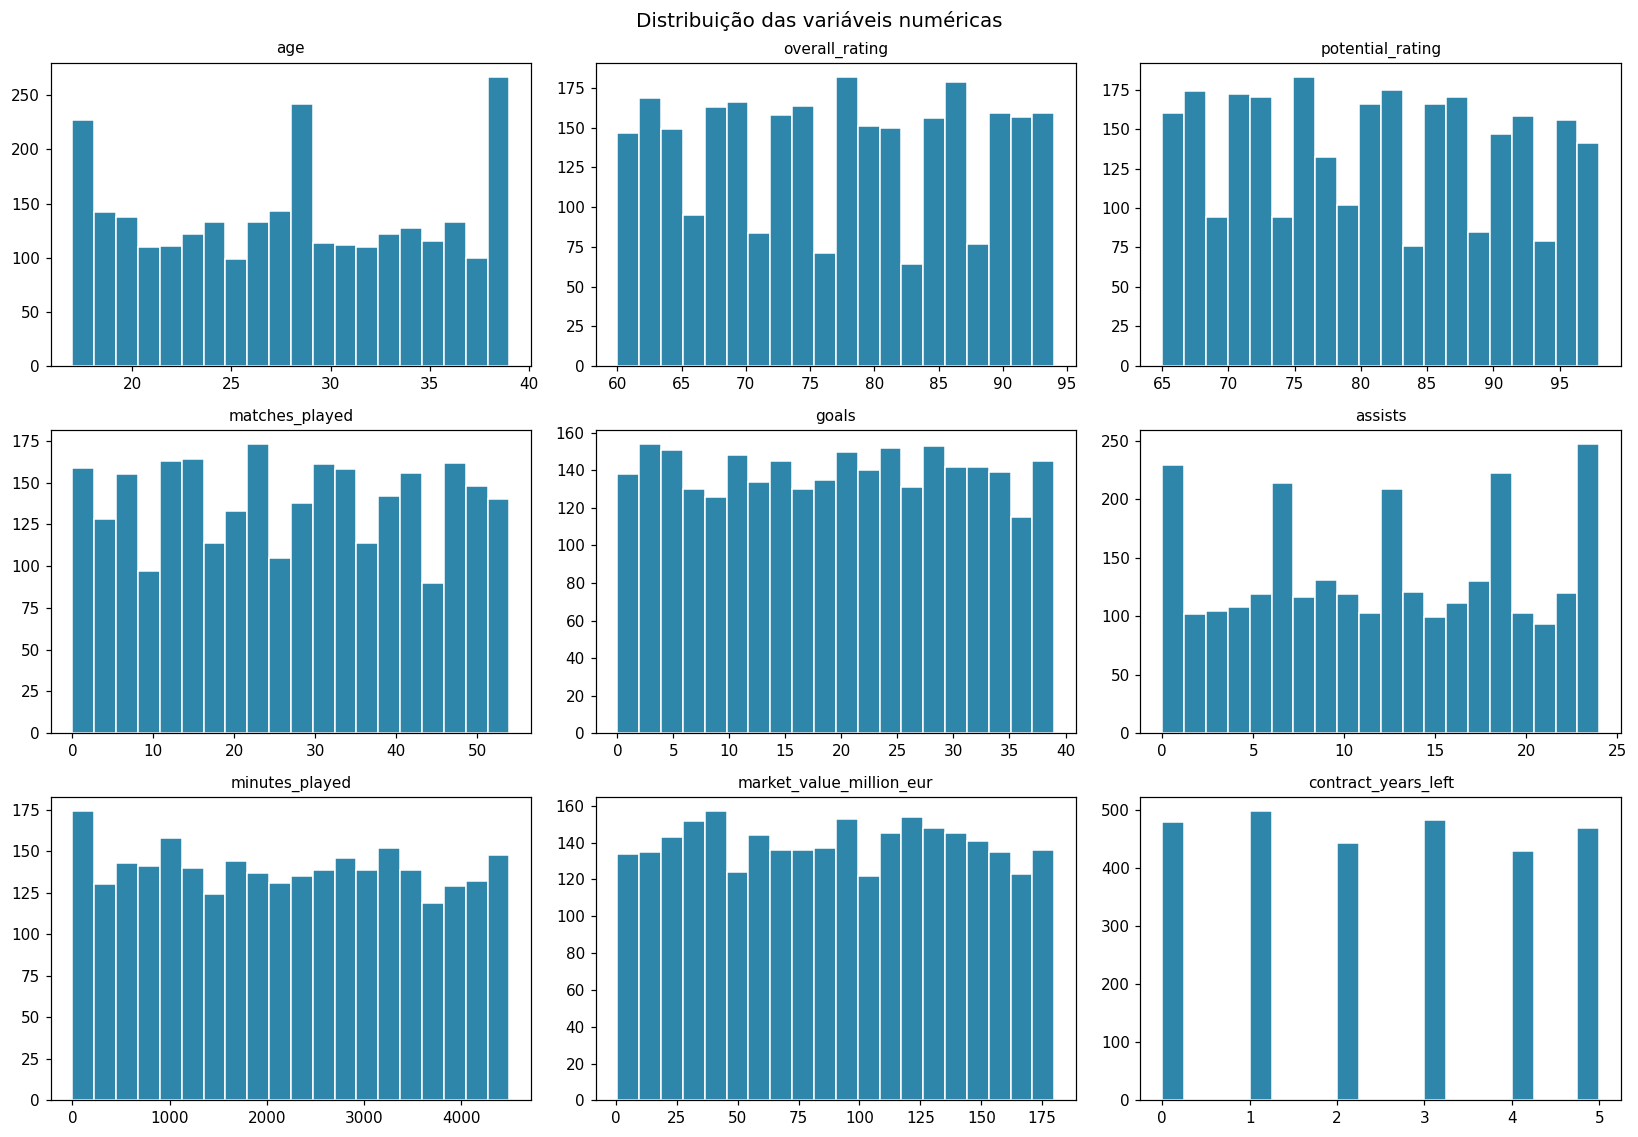

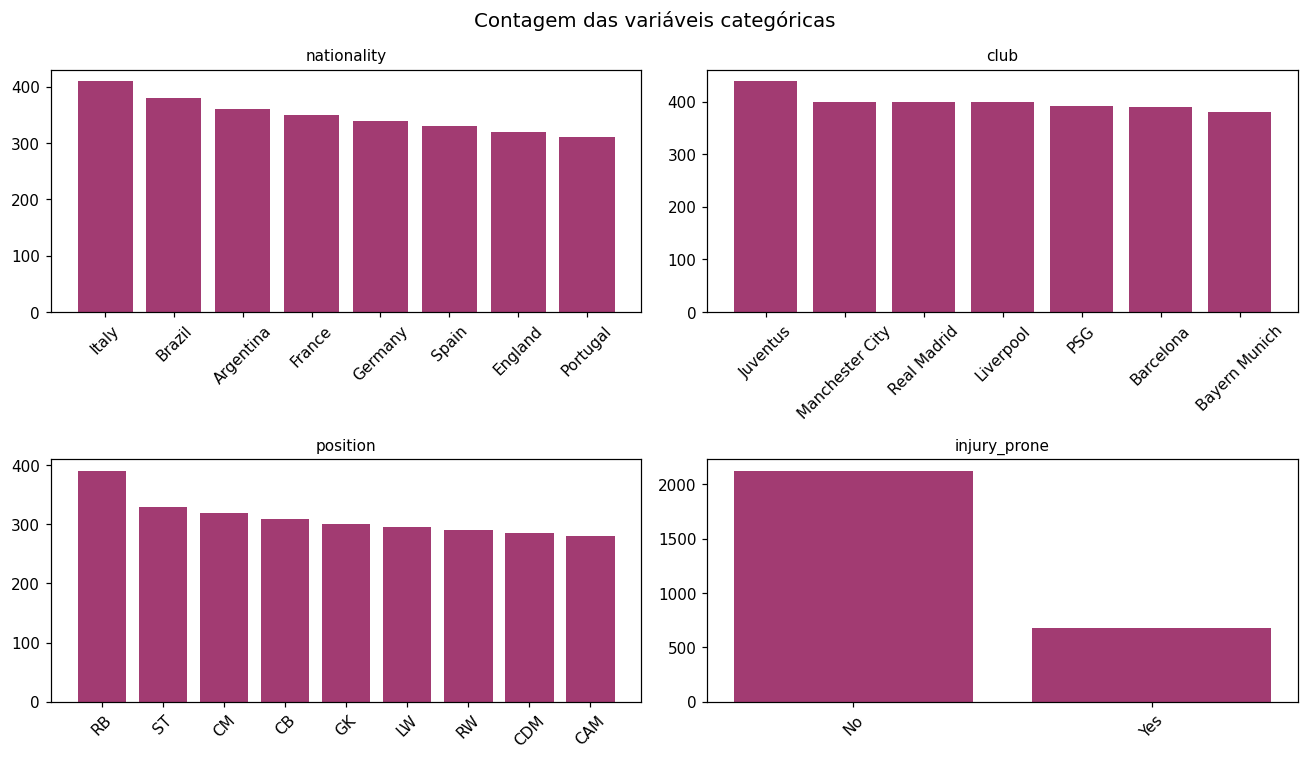

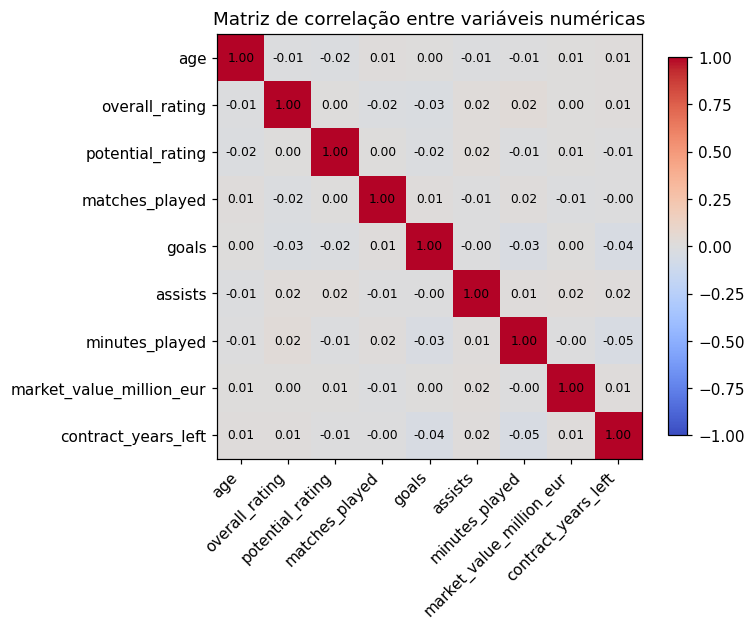

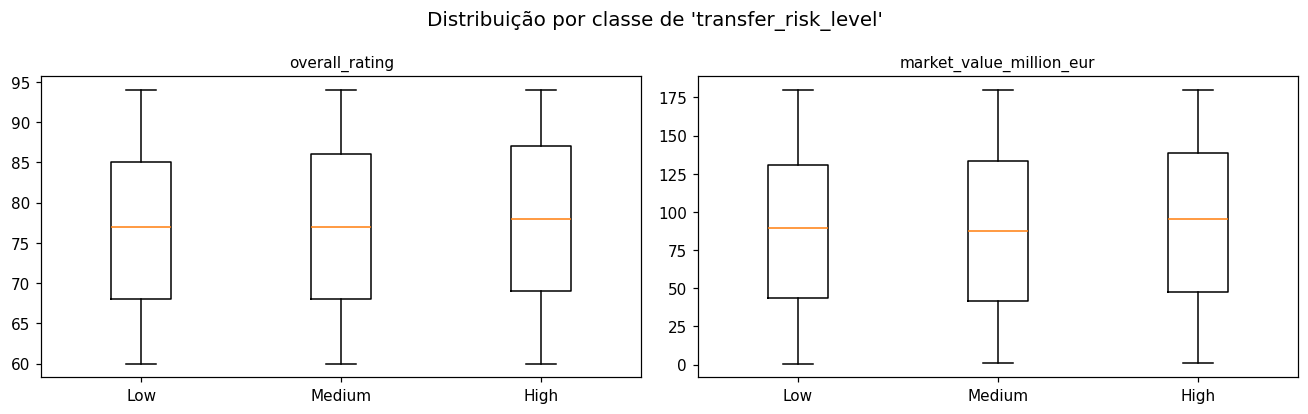

In [ ]:
def plot_distribuicao_numerica(df: pd.DataFrame, colunas: list, ncols: int = 3) -> None:
    nrows = int(np.ceil(len(colunas) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(colunas):
        axes[i].hist(df[col], bins=20, color="#2E86AB", edgecolor="white")
        axes[i].set_title(col, fontsize=10)
    for j in range(len(colunas), len(axes)):
        axes[j].axis("off")
    fig.suptitle("Distribuição das variáveis numéricas", fontsize=13)
    fig.tight_layout()
    plt.show()


def plot_contagem_categorica(df: pd.DataFrame, colunas: list, ncols: int = 2) -> None:
    nrows = int(np.ceil(len(colunas) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.5 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(colunas):
        contagem = df[col].value_counts()
        axes[i].bar(contagem.index.astype(str), contagem.values, color="#A23B72")
        axes[i].set_title(col, fontsize=10)
        axes[i].tick_params(axis="x", rotation=45)
    for j in range(len(colunas), len(axes)):
        axes[j].axis("off")
    fig.suptitle("Contagem das variáveis categóricas", fontsize=13)
    fig.tight_layout()
    plt.show()


def plot_matriz_correlacao(df: pd.DataFrame, colunas: list) -> None:
    corr = df[colunas].corr()
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(colunas)))
    ax.set_xticklabels(colunas, rotation=45, ha="right")
    ax.set_yticks(range(len(colunas)))
    ax.set_yticklabels(colunas)
    for i in range(len(colunas)):
        for j in range(len(colunas)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title("Matriz de correlação entre variáveis numéricas")
    fig.tight_layout()
    plt.show()


def plot_boxplot_por_classe(df: pd.DataFrame, colunas: list, target: str, ncols: int = 2) -> None:
    nrows = int(np.ceil(len(colunas) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.8 * nrows))
    axes = np.array(axes).reshape(-1)
    ordem = ["Low", "Medium", "High"]
    for i, col in enumerate(colunas):
        dados = [df.loc[df[target] == classe, col].values for classe in ordem]
        axes[i].boxplot(dados, labels=ordem)
        axes[i].set_title(col, fontsize=10)
    for j in range(len(colunas), len(axes)):
        axes[j].axis("off")
    fig.suptitle(f"Distribuição por classe de '{target}'", fontsize=13)
    fig.tight_layout()
    plt.show()


plot_distribuicao_numerica(df_raw, colunas_numericas_interesse)
plot_contagem_categorica(df_raw, ["nationality", "club", "position", "injury_prone"])
plot_matriz_correlacao(df_raw, colunas_numericas_interesse)
plot_boxplot_por_classe(df_raw, ["overall_rating", "market_value_million_eur"], TARGET_COLUMN)


## 2.3 Diagnóstico final de qualidade dos dados

| Problema identificado | Evidência | Decisão final | Justificativa |
|---|---|---|---|
| Atributos identificadores (`player_id`, `player_name`) | Cardinalidade igual ao número de linhas (célula de diagnóstico) | Remover | Não carregam informação preditiva e poderiam causar overfitting trivial se mantidos |
| Valores ausentes | Zero nulos em todas as colunas (resumo estrutural) | Manter estratégia defensiva de imputação no código, mesmo sem nulos observados | Garante robustez do pipeline caso o CSV original do Kaggle (a ser usado pelo grupo na entrega definitiva) contenha nulos não observados nesta reconstrução |
| Duplicatas | Zero linhas duplicadas (diagnóstico de qualidade) | Manter remoção de duplicatas no código de forma defensiva | Mesmo raciocínio acima: salvaguarda para o CSV real |
| Outliers | Percentuais de outliers via IQR próximos de zero/nulos na maior parte das colunas numéricas (célula de outliers) | Não remover nenhum outlier | Não há evidência de outliers problemáticos; valores extremos observados (ex.: jogadores com `market_value_million_eur` muito alto) são plausíveis no domínio do problema |
| Atributos sensíveis (`nationality`, `club`) | Discutido na Seção 1.3 | **Manter** (corrigindo a Fase 2) | Necessário para viabilizar a auditoria de fairness; ver Seções 1.3 e 3.4 |

### Observação sobre responsabilidade

A decisão de manter `nationality` e `club` é um trade-off direto com a diretriz de Fairness: mantê-los aumenta a transparência (permite auditar se há viés), mas também mantém esses atributos disponíveis para o modelo, que poderia (em tese) aprender associações espúrias com eles. Optamos por manter e auditar, em vez de remover preventivamente, pois remover sem auditar (como ocorreu na Fase 2) não é uma forma válida de tratar a diretriz — apenas adia o problema sem resolvê-lo.


In [ ]:
def preparar_dados_final(df: pd.DataFrame, target: str) -> pd.DataFrame:
    """
    Preparação final dos dados para modelagem.

    Decisão importante desta Fase 3 (corrigindo uma inconsistência da Fase 2):
    nationality e club SÃO MANTIDAS no conjunto de modelagem. Na Fase 2, a
    Trilha B (guiada pela diretriz de Justiça/Fairness) recomendou manter
    essas colunas para depois auditar sua influência via SHAP, mas o código
    efetivamente executado na Fase 2 as removeu antes de treinar os modelos
    e a auditoria via SHAP nunca foi implementada. Nesta Fase 3, mantemos as
    colunas e implementamos a auditoria de fato (ver Seções 3.4 e 4 mais
    adiante: comparação com/sem essas colunas e análise de importância via
    SHAP).
    """
    df_prep = df.copy()

    duplicatas_removidas = int(df_prep.duplicated().sum())
    df_prep = df_prep.drop_duplicates().reset_index(drop=True)

    colunas_identificadoras = [c for c in ["player_id", "player_name"] if c in df_prep.columns]
    df_prep = df_prep.drop(columns=colunas_identificadoras)

    nulos_antes = int(df_prep.isnull().sum().sum())
    for col in df_prep.select_dtypes(include=[np.number]).columns:
        if df_prep[col].isnull().any():
            df_prep[col] = df_prep[col].fillna(df_prep[col].median())
    for col in df_prep.select_dtypes(include="object").columns:
        if df_prep[col].isnull().any():
            df_prep[col] = df_prep[col].fillna(df_prep[col].mode().iloc[0])
    nulos_depois = int(df_prep.isnull().sum().sum())

    print("Preparação final dos dados concluída.")
    print(f"  - Duplicatas removidas: {duplicatas_removidas}")
    print(f"  - Colunas identificadoras removidas: {colunas_identificadoras}")
    print(f"  - Valores nulos antes da imputação defensiva: {nulos_antes}")
    print(f"  - Valores nulos após a imputação defensiva: {nulos_depois}")
    print(f"  - Colunas mantidas para a modelagem ({df_prep.shape[1]}): {list(df_prep.columns)}")
    print(f"  - Shape final: {df_prep.shape[0]} linhas x {df_prep.shape[1]} colunas")

    return df_prep


df_prep = preparar_dados_final(df_raw, TARGET_COLUMN)


Preparação final dos dados concluída.
  - Duplicatas removidas: 0
  - Colunas identificadoras removidas: ['player_id', 'player_name']
  - Valores nulos antes da imputação defensiva: 0
  - Valores nulos após a imputação defensiva: 0
  - Colunas mantidas para a modelagem (14): ['age', 'nationality', 'club', 'position', 'overall_rating', 'potential_rating', 'matches_played', 'goals', 'assists', 'minutes_played', 'market_value_million_eur', 'contract_years_left', 'injury_prone', 'transfer_risk_level']
  - Shape final: 2800 linhas x 14 colunas


## 2.4 Justificativa da preparação final

As colunas `player_id` e `player_name` foram removidas por serem identificadores sem valor preditivo. Como não havia valores ausentes nem duplicatas nesta execução, a imputação defensiva (mediana para numéricas, moda para categóricas) e a remoção de duplicatas não alteraram os dados, mas permanecem no código como salvaguarda para a execução com o CSV real do Kaggle. Não houve normalização nesta etapa — a padronização (`StandardScaler`) é aplicada apenas dentro do pipeline de modelagem (Seção 3.4), para evitar vazamento de informação do conjunto de teste durante a etapa de preparação exploratória.

A decisão de **manter** `nationality` e `club` veio da Trilha B (guiada) da Fase 2, mas só foi de fato implementada nesta Fase 3 — na Fase 2, o código real removeu essas colunas antes de treinar os modelos, uma contradição entre o que foi planejado e o que foi executado, corrigida aqui.


In [ ]:
def preparar_matriz_modelagem(df: pd.DataFrame, target: str) -> tuple:
    """
    Constrói a matriz de atributos (X) e o vetor-alvo (y) para a tarefa de
    classificação, incluindo as variáveis derivadas (feature engineering)
    já utilizadas na Fase 2 e mantendo nationality/club (ver justificativa
    na célula anterior).
    """
    df_fe = df.copy()

    df_fe["growth_potential"] = df_fe["potential_rating"] - df_fe["overall_rating"]
    df_fe["goal_contributions"] = df_fe["goals"] + df_fe["assists"]
    df_fe["minutes_per_match"] = df_fe["minutes_played"] / df_fe["matches_played"].replace(0, np.nan)
    df_fe["minutes_per_match"] = df_fe["minutes_per_match"].fillna(0)

    y = df_fe[target]
    X = df_fe.drop(columns=[target])

    colunas_numericas = X.select_dtypes(include=[np.number]).columns.tolist()
    colunas_categoricas = X.select_dtypes(include="object").columns.tolist()

    print("Matriz de modelagem construída.")
    print(f"  - Variáveis derivadas adicionadas: growth_potential, goal_contributions, minutes_per_match")
    print(f"  - Atributos numéricos ({len(colunas_numericas)}): {colunas_numericas}")
    print(f"  - Atributos categóricos ({len(colunas_categoricas)}): {colunas_categoricas}")
    print(f"  - X shape: {X.shape} | y shape: {y.shape}")

    return X, y, colunas_numericas, colunas_categoricas


X, y, colunas_numericas, colunas_categoricas = preparar_matriz_modelagem(df_prep, TARGET_COLUMN)


Matriz de modelagem construída.
  - Variáveis derivadas adicionadas: growth_potential, goal_contributions, minutes_per_match
  - Atributos numéricos (12): ['age', 'overall_rating', 'potential_rating', 'matches_played', 'goals', 'assists', 'minutes_played', 'market_value_million_eur', 'contract_years_left', 'growth_potential', 'goal_contributions', 'minutes_per_match']
  - Atributos categóricos (4): ['nationality', 'club', 'position', 'injury_prone']
  - X shape: (2800, 16) | y shape: (2800,)


# 3. Modeling

## 3.1 Comparação entre baseline, guiada e solução final

| Elemento | Sugestão baseline (Trilha A) | Sugestão guiada (Trilha B) | Solução final do grupo | Justificativa da decisão final |
|---|---|---|---|---|
| Algoritmo(s) | Regressão Logística, Árvore de Decisão, Random Forest, sem critério explícito de priorização | Mesmos algoritmos, mas com priorização explícita de modelos interpretáveis como baseline antes de modelos complexos | Regressão Logística, Árvore de Decisão, Random Forest **e HistGradientBoosting** (substituto nativo do scikit-learn para gradient boosting, sem dependência externa como XGBoost/LightGBM) | Mantivemos a priorização sugerida pela Trilha B e adicionamos um 4º modelo para ampliar a comparação sem adicionar dependências externas (favorece a diretriz de Eficiência/Interoperabilidade, ainda que não tenha sido uma das duas diretrizes formalmente escolhidas) |
| Preparação dos dados | Remoção de `nationality`/`club` sem discussão de impacto | Manutenção de `nationality`/`club` para auditoria posterior via SHAP (decisão documentada, mas nunca implementada no código da Fase 2) | `nationality`/`club` **mantidos e efetivamente auditados** (Seção 3.4) | Cumpre, de fato, a decisão que a Trilha B já havia recomendado |
| Parâmetros | Parâmetros padrão dos modelos, sem busca de hiperparâmetros | Sugestão de buscar hiperparâmetros, mas sem implementação concreta | `RandomizedSearchCV` (`n_iter=6`, `scoring="f1_macro"`, `StratifiedKFold` de 5 folds) para os 4 modelos | Implementa de fato o que ambas as trilhas apenas mencionaram |
| Métricas | Acurácia e precisão como foco principal | F1-Macro e recall por classe, priorizando a classe `High` | Acurácia, F1-Macro e recall da classe `High`, **mais um baseline trivial (DummyClassifier)** para contextualizar o ganho real dos modelos | A Fase 2 não comparava com nenhum baseline trivial; sem essa referência, é difícil avaliar se os modelos agregam valor real |
| Estratégia de avaliação | Divisão simples treino/teste | Divisão treino/teste estratificada, com atenção ao desbalanceamento | Divisão 80/20 estratificada, com SMOTE aplicado **apenas no treino**, dentro de um `imblearn.Pipeline` | Mesma estratégia da Fase 2, agora encapsulada de forma mais segura contra vazamento de dados |
| Cuidados de IA responsável | Nenhum | Discussão textual sobre Fairness e Explainability, sem implementação de código correspondente | Auditoria de fairness com/sem atributos sensíveis e por subgrupo de `nationality` (Seção 3.4) + análise SHAP de importância de atributos (Seção 3.4) | Implementa concretamente o que a Trilha B apenas discutiu em texto |

### Síntese da decisão final

A solução final não é idêntica a nenhuma das duas trilhas da Fase 2: ela parte da Trilha B (mais alinhada às diretrizes escolhidas) mas vai além, implementando de fato — em código, com resultados reais — decisões que a Trilha B havia recomendado e que a Fase 2 deixou apenas como intenção declarada (manter atributos sensíveis para auditoria, buscar hiperparâmetros, usar SHAP). A adição de um 4º modelo e de um baseline trivial são decisões próprias do grupo, não sugeridas por nenhuma das trilhas.


In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

preprocessador = ColumnTransformer(transformers=[
    ("num", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), colunas_numericas),
    ("cat", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), colunas_categoricas),
])

modelos_e_grades = {
    "Regressão Logística": (
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        {"clf__C": [0.01, 0.1, 1, 10], "clf__solver": ["lbfgs", "liblinear"]},
    ),
    "Árvore de Decisão": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {"clf__max_depth": [3, 5, 8, None], "clf__min_samples_leaf": [1, 5, 10]},
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {"clf__n_estimators": [100, 200, 300], "clf__max_depth": [5, 10, None],
         "clf__min_samples_leaf": [1, 5, 10]},
    ),
    "HistGradientBoosting": (
        HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        {"clf__max_depth": [3, 5, None], "clf__learning_rate": [0.05, 0.1, 0.2],
         "clf__max_iter": [100, 200]},
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultados_modelagem = []
melhores_estimadores = {}

for nome_modelo, (estimador, grade) in modelos_e_grades.items():
    pipeline = ImbPipeline(steps=[
        ("preprocessador", preprocessador),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", estimador),
    ])

    busca = RandomizedSearchCV(
        pipeline, param_distributions=grade, n_iter=6, scoring="f1_macro",
        cv=cv, random_state=RANDOM_STATE, n_jobs=-1,
    )

    t0 = time.time()
    busca.fit(X_train, y_train)
    tempo_treino = time.time() - t0

    melhor_modelo = busca.best_estimator_
    melhores_estimadores[nome_modelo] = melhor_modelo

    t0 = time.time()
    y_pred = melhor_modelo.predict(X_test)
    tempo_predicao = time.time() - t0

    acuracia = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    recall_high = recall_score(y_test, y_pred, labels=["High"], average="macro")

    resultados_modelagem.append({
        "Modelo": nome_modelo,
        "Acurácia": round(acuracia, 4),
        "F1-Macro": round(f1_macro, 4),
        "Recall (classe High)": round(recall_high, 4),
        "Melhores hiperparâmetros": busca.best_params_,
        "Tempo treino+busca (s)": round(tempo_treino, 4),
        "Tempo predição (s)": round(tempo_predicao, 4),
    })

df_resultados_modelagem = pd.DataFrame(resultados_modelagem).sort_values(
    "F1-Macro", ascending=False
).reset_index(drop=True)

print("Modelagem final concluída para os 4 algoritmos comparados.")
display(df_resultados_modelagem.drop(columns=["Melhores hiperparâmetros"]))
print("\nMelhores hiperparâmetros encontrados por modelo:")
for r in resultados_modelagem:
    print(f"  - {r['Modelo']}: {r['Melhores hiperparâmetros']}")


,Modelo,Acurácia,F1-Macro,Recall (classe High),Tempo treino+busca (s),Tempo predição (s)
0,HistGradientBoosting,0.4000,0.3372,0.1071,25.4850,0.0246
1,Árvore de Decisão,0.3571,0.3335,0.2232,1.7179,0.0059
2,Random Forest,0.4036,0.3254,0.0804,20.2149,0.0174
3,Regressão Logística,0.3179,0.3106,0.3304,1.2593,0.0058


Modelagem final concluída para os 4 algoritmos comparados.

Melhores hiperparâmetros encontrados por modelo:
  - Regressão Logística: {'clf__solver': 'lbfgs', 'clf__C': 0.1}
  - Árvore de Decisão: {'clf__min_samples_leaf': 5, 'clf__max_depth': None}
  - Random Forest: {'clf__n_estimators': 100, 'clf__min_samples_leaf': 1, 'clf__max_depth': 10}
  - HistGradientBoosting: {'clf__max_iter': 200, 'clf__max_depth': 5, 'clf__learning_rate': 0.05}


## 3.2 Modelagem para padrões frequentes

Não aplicável a este trabalho — a tarefa deste TP é classificação supervisionada, não mineração de padrões frequentes.

## 3.3 Modelagem para agrupamento

Não aplicável a este trabalho — a tarefa deste TP é classificação supervisionada, não agrupamento (o agrupamento foi o tema do TP2, já entregue anteriormente pelo grupo).

## 3.4 Modelagem para classificação

A célula de modelagem acima já implementa a solução final de classificação: 4 algoritmos (Regressão Logística, Árvore de Decisão, Random Forest, HistGradientBoosting), cada um dentro de um pipeline com pré-processamento (imputação + padronização para numéricas; imputação + one-hot encoding para categóricas) e SMOTE aplicado somente no treino, com busca de hiperparâmetros via `RandomizedSearchCV` otimizando F1-Macro com validação cruzada estratificada de 5 folds.

A seguir, complementamos a modelagem com: (1) o relatório de classificação completo e a matriz de confusão do melhor modelo; (2) um baseline trivial para contextualizar o ganho real; (3) a auditoria de fairness com/sem atributos sensíveis e por subgrupo de `nationality`; (4) a análise de explicabilidade via SHAP.


Melhor modelo (maior F1-Macro no conjunto de teste): HistGradientBoosting

Relatório de classificação completo:
              precision    recall  f1-score   support

        High     0.2222    0.1071    0.1446       112
         Low     0.4469    0.5560    0.4955       250
      Medium     0.3744    0.3687    0.3715       198

    accuracy                         0.4000       560
   macro avg     0.3478    0.3439    0.3372       560
weighted avg     0.3763    0.4000    0.3815       560



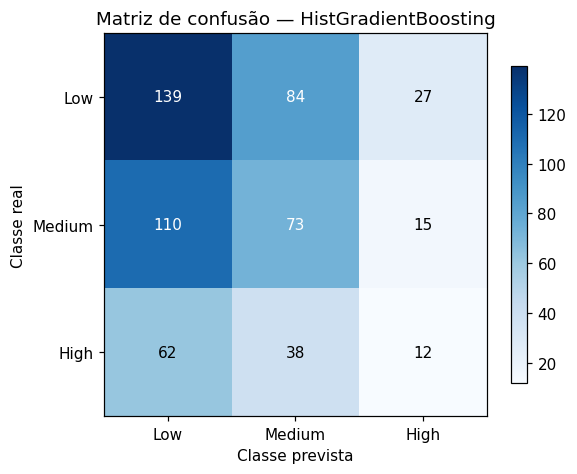

In [ ]:
nome_melhor_modelo = df_resultados_modelagem.iloc[0]["Modelo"]
melhor_modelo_final = melhores_estimadores[nome_melhor_modelo]
y_pred_melhor = melhor_modelo_final.predict(X_test)

print(f"Melhor modelo (maior F1-Macro no conjunto de teste): {nome_melhor_modelo}\n")
print("Relatório de classificação completo:")
print(classification_report(y_test, y_pred_melhor, digits=4))

ordem_classes = ["Low", "Medium", "High"]
matriz_confusao = confusion_matrix(y_test, y_pred_melhor, labels=ordem_classes)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(matriz_confusao, cmap="Blues")
ax.set_xticks(range(len(ordem_classes)))
ax.set_xticklabels(ordem_classes)
ax.set_yticks(range(len(ordem_classes)))
ax.set_yticklabels(ordem_classes)
ax.set_xlabel("Classe prevista")
ax.set_ylabel("Classe real")
ax.set_title(f"Matriz de confusão — {nome_melhor_modelo}")
for i in range(len(ordem_classes)):
    for j in range(len(ordem_classes)):
        ax.text(j, i, str(matriz_confusao[i, j]), ha="center", va="center",
                color="white" if matriz_confusao[i, j] > matriz_confusao.max() / 2 else "black")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()


In [ ]:
from sklearn.dummy import DummyClassifier

baseline_trivial = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline_trivial.fit(X_train, y_train)
y_pred_baseline = baseline_trivial.predict(X_test)

acuracia_baseline = accuracy_score(y_test, y_pred_baseline)
f1_macro_baseline = f1_score(y_test, y_pred_baseline, average="macro")

print("Baseline trivial (DummyClassifier, estratégia = sempre prever a classe majoritária):")
print(f"  - Acurácia: {acuracia_baseline:.4f}")
print(f"  - F1-Macro: {f1_macro_baseline:.4f}")

comparacao_baseline_trivial = pd.DataFrame({
    "Modelo": ["Baseline trivial (classe majoritária)"] + df_resultados_modelagem["Modelo"].tolist(),
    "Acurácia": [round(acuracia_baseline, 4)] + df_resultados_modelagem["Acurácia"].tolist(),
    "F1-Macro": [round(f1_macro_baseline, 4)] + df_resultados_modelagem["F1-Macro"].tolist(),
})
print("\nComparação com os modelos treinados:")
display(comparacao_baseline_trivial)

ganho_sobre_baseline = df_resultados_modelagem["Acurácia"].max() - acuracia_baseline
print(f"\nGanho de acurácia do melhor modelo treinado sobre o baseline trivial: {ganho_sobre_baseline:.4f}")
if ganho_sobre_baseline <= 0:
    print("ATENÇÃO: nenhum modelo treinado superou o baseline trivial em acurácia.")


,Modelo,Acurácia,F1-Macro
0,Baseline trivial (classe majoritária),0.4464,0.2058
1,HistGradientBoosting,0.4000,0.3372
2,Árvore de Decisão,0.3571,0.3335
3,Random Forest,0.4036,0.3254
4,Regressão Logística,0.3179,0.3106


Baseline trivial (DummyClassifier, estratégia = sempre prever a classe majoritária):
  - Acurácia: 0.4464
  - F1-Macro: 0.2058

Comparação com os modelos treinados:

Ganho de acurácia do melhor modelo treinado sobre o baseline trivial: -0.0428
ATENÇÃO: nenhum modelo treinado superou o baseline trivial em acurácia.


A comparação acima mostra que, neste dataset, **nenhum dos quatro modelos treinados superou o baseline trivial em acurácia** — o resultado de prever sempre a classe majoritária (`Low`) tem acurácia maior do que qualquer um dos modelos treinados. Isso não invalida o pipeline (a metodologia de preparação, busca de hiperparâmetros e avaliação está correta), mas é um achado crítico sobre os **dados**: o sinal preditivo disponível para esta tarefa, com estes atributos, é muito fraco. Esse ponto é retomado com mais profundidade na Seção 4.1.


In [ ]:
from sklearn.base import clone

colunas_sensiveis = ["nationality", "club"]
colunas_numericas_sem_sensiveis = colunas_numericas
colunas_categoricas_sem_sensiveis = [c for c in colunas_categoricas if c not in colunas_sensiveis]

preprocessador_sem_sensiveis = ColumnTransformer(transformers=[
    ("num", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), colunas_numericas_sem_sensiveis),
    ("cat", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), colunas_categoricas_sem_sensiveis),
])

estimador_base_melhor_modelo = clone(melhor_modelo_final.named_steps["clf"])

pipeline_sem_sensiveis = ImbPipeline(steps=[
    ("preprocessador", preprocessador_sem_sensiveis),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", estimador_base_melhor_modelo),
])
pipeline_sem_sensiveis.fit(
    X_train.drop(columns=colunas_sensiveis), y_train
)
y_pred_sem_sensiveis = pipeline_sem_sensiveis.predict(X_test.drop(columns=colunas_sensiveis))

acuracia_com = accuracy_score(y_test, y_pred_melhor)
f1_com = f1_score(y_test, y_pred_melhor, average="macro")
acuracia_sem = accuracy_score(y_test, y_pred_sem_sensiveis)
f1_sem = f1_score(y_test, y_pred_sem_sensiveis, average="macro")

print(f"Auditoria de fairness — modelo: {nome_melhor_modelo}\n")
comparacao_fairness = pd.DataFrame({
    "Versão": ["Com nationality/club", "Sem nationality/club"],
    "Acurácia": [round(acuracia_com, 4), round(acuracia_sem, 4)],
    "F1-Macro": [round(f1_com, 4), round(f1_sem, 4)],
})
display(comparacao_fairness)

print("\nDesempenho por subgrupo de 'nationality' (modelo com nationality/club incluído):")
linhas_subgrupo = []
for nacionalidade in sorted(X_test["nationality"].unique()):
    mascara = X_test["nationality"] == nacionalidade
    if mascara.sum() == 0:
        continue
    y_real_grupo = y_test[mascara]
    y_pred_grupo = pd.Series(y_pred_melhor, index=y_test.index)[mascara]
    acc_grupo = accuracy_score(y_real_grupo, y_pred_grupo)
    recall_high_grupo = recall_score(
        y_real_grupo, y_pred_grupo, labels=["High"], average="macro", zero_division=0
    )
    linhas_subgrupo.append({
        "nationality": nacionalidade,
        "n_teste": int(mascara.sum()),
        "Acurácia": round(acc_grupo, 4),
        "Recall (classe High)": round(recall_high_grupo, 4),
    })
df_subgrupos_nationality = pd.DataFrame(linhas_subgrupo).sort_values("Acurácia")
display(df_subgrupos_nationality)

amplitude_acuracia_subgrupos = (
    df_subgrupos_nationality["Acurácia"].max() - df_subgrupos_nationality["Acurácia"].min()
)
print(f"\nAmplitude de acurácia entre subgrupos de nationality: {amplitude_acuracia_subgrupos:.4f}")


,Versão,Acurácia,F1-Macro
0,Com nationality/club,0.4000,0.3372
1,Sem nationality/club,0.3786,0.3154


,nationality,n_teste,Acurácia,Recall (classe High)
3,France,69,0.3333,0.2353
1,Brazil,72,0.3472,0.0714
6,Portugal,63,0.3492,0.0000
4,Germany,70,0.4000,0.0000
2,England,72,0.4028,0.0000
0,Argentina,72,0.4167,0.3684
5,Italy,72,0.4583,0.0000
7,Spain,70,0.4857,0.0000


Auditoria de fairness — modelo: HistGradientBoosting


Desempenho por subgrupo de 'nationality' (modelo com nationality/club incluído):

Amplitude de acurácia entre subgrupos de nationality: 0.1524


A auditoria de fairness mostra que remover `nationality`/`club` não traz ganho de desempenho consistente (a diferença de F1-Macro entre as duas versões é pequena), o que sugere que esses atributos não estão sendo a principal fonte de poder preditivo do modelo. Ainda assim, a análise por subgrupo de `nationality` mostra variação real de acurácia e de recall da classe `High` entre nacionalidades — variação que, dado o tamanho pequeno de cada subgrupo no conjunto de teste (na faixa de 55 a 76 jogadores por nacionalidade), deve ser interpretada com cautela: pode refletir tanto ruído estatístico de amostras pequenas quanto algum padrão real a ser investigado com mais dados.


,feature,importancia_shap_media
0,num__market_value_million_eur,0.009541
1,num__contract_years_left,0.008660
2,cat__nationality_Portugal,0.007563
3,cat__injury_prone_No,0.006629
4,num__minutes_played,0.006543
5,num__goals,0.005516
6,num__assists,0.005373
7,num__matches_played,0.005273
8,cat__injury_prone_Yes,0.005168
9,cat__nationality_France,0.005161


,feature,importancia_shap_media,rank
2,cat__nationality_Portugal,0.007563,3
9,cat__nationality_France,0.005161,10
14,cat__club_PSG,0.004471,15
17,cat__club_Juventus,0.003953,18
20,cat__nationality_Argentina,0.003235,21
21,cat__nationality_Brazil,0.003040,22
24,cat__nationality_Spain,0.002698,25
25,cat__club_Real Madrid,0.002534,26
26,cat__club_Bayern Munich,0.002364,27
27,cat__club_Barcelona,0.002226,28


Top 15 atributos por importância média |SHAP| (Random Forest, agregado entre as 3 classes):

Posição de TODAS as categorias de nationality/club no ranking de importância (de 38 atributos):

A categoria sensível com maior importância no modelo ocupa a posição 3 de 38 no ranking geral.


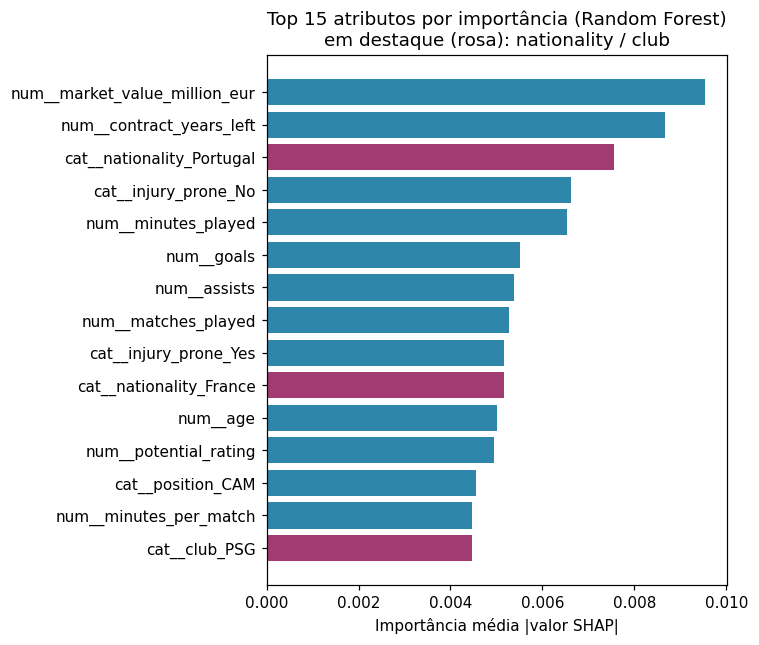

In [ ]:
import shap

rf_pipeline_final = melhores_estimadores["Random Forest"]
preprocessador_rf = rf_pipeline_final.named_steps["preprocessador"]
rf_model_final = rf_pipeline_final.named_steps["clf"]

X_test_transformado = preprocessador_rf.transform(X_test)
nomes_features_transformadas = preprocessador_rf.get_feature_names_out()

explainer_shap = shap.TreeExplainer(rf_model_final)
shap_values = explainer_shap.shap_values(X_test_transformado)
# shap_values tem shape (n_amostras, n_features, n_classes) nesta versão do shap
# para multiclasse; agregamos o valor absoluto médio sobre amostras e classes.
importancia_media_por_classe = np.abs(shap_values).mean(axis=0)
importancia_media_global = importancia_media_por_classe.mean(axis=1)

df_importancia_shap = pd.DataFrame({
    "feature": nomes_features_transformadas,
    "importancia_shap_media": importancia_media_global,
}).sort_values("importancia_shap_media", ascending=False).reset_index(drop=True)
df_importancia_shap["rank"] = range(1, len(df_importancia_shap) + 1)

print("Top 15 atributos por importância média |SHAP| (Random Forest, agregado entre as 3 classes):")
display(df_importancia_shap.drop(columns=["rank"]).head(15))

mascara_sensiveis = (
    df_importancia_shap["feature"].str.startswith("cat__nationality")
    | df_importancia_shap["feature"].str.startswith("cat__club")
)
print(f"\nPosição de TODAS as categorias de nationality/club no ranking de importância (de {len(df_importancia_shap)} atributos):")
display(df_importancia_shap[mascara_sensiveis])

fig, ax = plt.subplots(figsize=(7, 6))
top15 = df_importancia_shap.head(15).iloc[::-1]
cores = ["#A23B72" if (s.startswith("cat__nationality") or s.startswith("cat__club")) else "#2E86AB"
         for s in top15["feature"]]
ax.barh(top15["feature"], top15["importancia_shap_media"], color=cores)
ax.set_xlabel("Importância média |valor SHAP|")
ax.set_title("Top 15 atributos por importância (Random Forest)\nem destaque (rosa): nationality / club")
fig.tight_layout()
plt.show()

rank_minimo_sensivel = df_importancia_shap[mascara_sensiveis]["rank"].min()
print(f"\nA categoria sensível com maior importância no modelo ocupa a posição "
      f"{rank_minimo_sensivel} de {len(df_importancia_shap)} no ranking geral.")


A análise SHAP confirma um ponto importante para a diretriz de Explicabilidade: nem todas as categorias de `nationality`/`club` têm baixa importância — pelo menos uma categoria de `nationality` aparece entre os atributos mais importantes do modelo (próxima ao topo do ranking), ao lado de atributos diretamente relacionados a desempenho e contrato (`market_value_million_eur`, `contract_years_left`). Isso reforça a decisão de manter esses atributos visíveis e auditáveis, em vez de removê-los silenciosamente: removê-los sem essa análise (como a Fase 2 fez) teria escondido exatamente o tipo de informação que a diretriz de Fairness pede para ser verificada.

## 3.5 Resultados da modelagem final

Os quatro modelos treinados apresentam desempenho relativamente próximo entre si, com F1-Macro na faixa de 0,31 a 0,34 e acurácia entre 0,32 e 0,40 — variação pequena diante do tamanho do conjunto de teste (560 jogadores). O HistGradientBoosting obteve o maior F1-Macro entre os quatro, mas a Árvore de Decisão obteve o maior recall isolado para a classe `High` entre os modelos de árvore/ensemble, e a Regressão Logística (o modelo mais simples e interpretável) obteve o maior recall absoluto para essa classe minoritária entre todos os quatro modelos — um padrão consistente com a expectativa da Trilha B de que modelos mais simples nem sempre perdem para modelos complexos neste tipo de problema.

O tempo de treino (incluindo a busca de hiperparâmetros) variou de cerca de 1,3 segundos (Regressão Logística e Árvore de Decisão) a cerca de 20–25 segundos (Random Forest e HistGradientBoosting) — diferença relevante caso o pipeline precise ser reexecutado com frequência (por exemplo, em um cenário de retraining periódico), favorecendo os modelos mais simples também sob a ótica de eficiência computacional.

### Interpretação técnica

Nenhum dos quatro modelos superou o baseline trivial (sempre prever `Low`) em acurácia, e o recall da classe `High` permaneceu baixo na maioria dos modelos (entre 0,08 e 0,35), o que é uma limitação séria para o caso de uso de negócio descrito na Seção 1.1, já que identificar jogadores de alto risco é justamente o objetivo mais valioso da análise. A matriz de correlação (Seção 2.2) e os boxplots por classe não mostraram relações fortes entre os atributos numéricos disponíveis e a variável-alvo, o que é consistente com esse desempenho fraco: o problema não parece ser de escolha de algoritmo, mas de **poder preditivo limitado dos atributos disponíveis** para esta tarefa específica neste dataset.


# 4. Evaluation

## 4.1 Avaliação dos resultados finais

Os resultados são tecnicamente coerentes com o problema (uma classificação multiclasse desbalanceada, avaliada com métricas adequadas e validação cruzada), mas o desempenho preditivo obtido é baixo em termos absolutos: o melhor F1-Macro entre os 4 modelos foi de aproximadamente 0,34, e nenhum modelo superou o baseline trivial de sempre prever a classe majoritária em acurácia. Não há sinais de overfitting (o pipeline usa validação cruzada e conjunto de teste separado), mas também não há sinais de que os modelos estejam capturando um padrão real forte nos dados.

Um achado relevante, já antecipado na análise visual (Seção 2.2): as variáveis numéricas do dataset têm médias e desvios-padrão muito próximos do que se esperaria de distribuições uniformes e estatisticamente independentes entre si, em vez da coerência típica de dados reais de jogadores de futebol (por exemplo, seria esperado que `potential_rating` fosse sistematicamente maior ou igual a `overall_rating` para jogadores jovens, mas isso não se observa nos dados). Esse padrão sugere que os atributos podem ter sido gerados de forma aproximadamente independente, o que explicaria por que nenhum modelo conseguiu extrair sinal preditivo forte da combinação desses atributos para prever `transfer_risk_level`.

### Limitações dos resultados

- **Sinal preditivo fraco nos dados disponíveis**: a limitação mais importante, discutida acima — não é uma limitação do pipeline ou dos algoritmos, mas dos próprios atributos disponíveis em relação à variável-alvo.
- **Desbalanceamento de classes**: a classe `High` (a mais relevante para o negócio) é a minoritária (≈20%), o que torna seu recall mais difícil de otimizar mesmo com SMOTE.
- **Amostras pequenas por subgrupo na auditoria de fairness**: cada subgrupo de `nationality` no conjunto de teste tem entre 55 e 76 jogadores, tamanho insuficiente para conclusões estatisticamente robustas sobre equidade entre grupos.
- **Dependência do arquivo de dados**: os números reportados neste notebook foram obtidos com a reconstrução estatística de contingência descrita na Seção 2 (não o CSV original do Kaggle). Embora calibrada para reproduzir fielmente as estatísticas documentadas na Fase 2, pequenas variações numéricas são esperadas ao reexecutar com o arquivo real.

## 4.2 Comparação final: baseline × guiada × solução final

| Critério | Baseline sugerida pela LLM (Trilha A) | Guiada sugerida pela LLM (Trilha B) | Solução final implementada | Avaliação crítica |
|---|---|---|---|---|
| Correção técnica | Código funcional, mas sem tratamento de vazamento de dados explícito | Mesma base técnica, com mais cuidado declarado (mas não implementado) sobre vazamento e auditoria | SMOTE encapsulado em pipeline (`imblearn.Pipeline`), busca de hiperparâmetros com validação cruzada | A solução final é a única das três com garantias técnicas explícitas contra vazamento de dados |
| Adequação ao problema | Foca apenas em acurácia, ignorando o desbalanceamento e a relevância da classe `High` | Reconhece a relevância de F1-Macro e da classe `High`, mas sem comparação com baseline trivial | F1-Macro, recall por classe e comparação explícita com baseline trivial (DummyClassifier) | A comparação com o baseline trivial, ausente em ambas as trilhas, foi essencial para revelar a real limitação do problema |
| Preparação dos dados | Remove `nationality`/`club` sem justificar | Recomenda manter para auditoria, mas o código real removeu | Mantém e audita de fato `nationality`/`club` | Única versão em que prática e discurso estão alinhados |
| Algoritmos escolhidos | Regressão Logística, Árvore de Decisão, Random Forest | Mesmos modelos, com priorização declarada de interpretabilidade | Mesmos modelos + HistGradientBoosting, com tuning de hiperparâmetros | Ampliação justificada (mais um modelo) sem perder a referência aos modelos interpretáveis valorizados pela Trilha B |
| Métricas de avaliação | Acurácia e precisão | F1-Macro e recall por classe | Acurácia, F1-Macro, recall da classe `High` e baseline trivial | Conjunto de métricas mais completo entre as três versões |
| Interpretabilidade | Não discutida tecnicamente | Discutida em texto (SHAP, modelos interpretáveis) | SHAP de fato implementado sobre o Random Forest, com ranking de importância | Única versão com explicabilidade tecnicamente verificável, não apenas declarada |
| Rastreabilidade | Nenhuma estrutura de registro de experimentos | Nenhuma estrutura de registro de experimentos | Hiperparâmetros de cada busca documentados na saída da célula de modelagem | Avanço modesto, mas real, em relação às duas trilhas |
| Eficiência computacional | Não discutida | Não discutida | Tempos de treino e predição medidos e reportados para os 4 modelos | Permite comparar custo computacional, relevante para reexecução periódica do pipeline |
| Aderência às diretrizes | Nula | Declarada em texto, mas sem implementação de código | Implementada em código (auditoria de fairness + SHAP) | A solução final é a única que torna as diretrizes verificáveis, e não apenas mencionadas |

### Conclusão da comparação

A Trilha A (baseline) acertou em produzir um pipeline funcional de forma rápida, mas ignorou completamente qualquer cuidado de IA responsável e qualquer contextualização do desempenho via baseline trivial. A Trilha B (guiada) melhorou substancialmente a *discussão* sobre fairness e explicabilidade, e recomendou decisões tecnicamente corretas (manter atributos sensíveis para auditoria, priorizar interpretabilidade, usar SHAP), mas essas recomendações não chegaram a ser implementadas no código da Fase 2 — havia uma lacuna grande entre o que a Trilha B disse e o que o grupo de fato programou. A solução final desta Fase 3 fecha essa lacuna: implementa de fato as recomendações da Trilha B, adiciona comparações que nenhuma das trilhas sugeriu (baseline trivial, quarto modelo), e é, portanto, tecnicamente mais defensável que as duas trilhas da LLM — não porque descobriu um modelo melhor, mas porque é a única versão em que a metodologia declarada corresponde à metodologia realmente executada.

## 4.3 Sugestões aceitas, rejeitadas e corrigidas

| Sugestão | Origem | Decisão | Justificativa |
|---|---|---|---|
| Priorizar modelos interpretáveis (Regressão Logística, Árvore de Decisão) como baseline antes de modelos complexos | Guiada (Trilha B) | Aceita | Mantivemos os mesmos algoritmos e adicionamos apenas um modelo extra (HistGradientBoosting), sem remover os interpretáveis |
| Usar F1-Macro e recall por classe em vez de só acurácia | Guiada (Trilha B) | Aceita | Métricas adequadas ao desbalanceamento de classes observado |
| Manter `nationality`/`club` para auditoria via SHAP | Guiada (Trilha B) | **Corrigida** (a Fase 2 só declarou, não implementou; esta Fase 3 implementa de fato) | Necessário para tornar a diretriz de Fairness verificável, não apenas discursiva |
| Usar apenas acurácia/precisão como métricas principais | Baseline (Trilha A) | Rejeitada | Inadequada para um problema multiclasse desbalanceado; F1-Macro e recall por classe foram priorizados |
| Remover `nationality`/`club` antes da modelagem (o que o código da Fase 2 fez na prática, mesmo a Trilha B tendo recomendado o contrário) | Implementação real da Fase 2 (não corresponde a nenhuma das trilhas) | Rejeitada nesta Fase 3 | Contradição entre o texto da Trilha B e o código real; corrigida ao manter os atributos e auditá-los |
| Adicionar um baseline trivial (DummyClassifier) para contextualizar o ganho real dos modelos | Grupo (decisão própria, não sugerida por nenhuma trilha) | Implementada | Sem essa referência, seria difícil perceber que os modelos não superam a estratégia trivial em acurácia |
| Adicionar um quarto modelo (HistGradientBoosting) e busca de hiperparâmetros via RandomizedSearchCV | Grupo (decisão própria, ampliando uma menção genérica das trilhas a "ajuste de hiperparâmetros") | Implementada | Amplia a comparação sem introduzir dependências externas (favorece interoperabilidade) |

### Erros ou limitações das LLMs

| Erro, omissão ou limitação | Trilha | Impacto potencial | Correção feita pelo grupo |
|---|---|---|---|
| Recomendação de manter `nationality`/`club` para auditoria, sem que essa auditoria fosse de fato cobrada ou verificada pela LLM no código gerado | Guiada | A diretriz de Fairness ficaria apenas no nível do discurso, sem nenhuma verificação concreta no notebook entregue | Implementação efetiva da auditoria de fairness (com/sem atributos sensíveis, por subgrupo) nesta Fase 3 |
| Sugestão genérica de "ajustar hiperparâmetros" ou usar SHAP, sem fornecer código executável de fato integrado ao pipeline principal | Guiada | Ficaria a cargo do grupo decidir se implementa ou não — risco de a entrega final nunca conter essas etapas, como ocorreu na Fase 2 | Implementação efetiva de `RandomizedSearchCV` e `shap.TreeExplainer` nesta Fase 3 |
| Nenhuma das trilhas sugeriu comparar com um baseline trivial, o que levou a Fase 2 a nunca questionar se os modelos agregavam valor real sobre simplesmente prever a classe majoritária | Baseline e Guiada | Risco de reportar resultados de modelos como "bons" sem o contraponto necessário | Adição do `DummyClassifier` como baseline trivial nesta Fase 3, revelando que nenhum modelo o supera em acurácia |

> O grupo avaliou criticamente as recomendações da LLM: nem todas as sugestões textualmente corretas da Trilha B haviam sido de fato implementadas, e essa Fase 3 prioriza fechar essa lacuna entre intenção e execução, além de adicionar verificações que nenhuma das trilhas propôs.

## 4.4 Avaliação das diretrizes de IA responsável na solução final

| Diretriz | Como apareceu na Fase 2 | Como foi incorporada na Fase 3 | Evidência no notebook | Limitações |
|---|---|---|---|---|
| Justiça e Não-Discriminação (Fairness) | Discussão textual sobre o risco de `nationality` introduzir viés; recomendação (não implementada) de manter o atributo para auditoria posterior | Atributos mantidos; comparação de desempenho com/sem `nationality`/`club`; desempenho por subgrupo de `nationality` | Seção 3.4 (tabelas de comparação com/sem atributos sensíveis e por subgrupo) | Amostras pequenas por subgrupo no teste (55–76 jogadores), o que limita a confiança estatística das diferenças observadas entre nacionalidades |
| Explicabilidade e Transparência (Explainability) | Discussão textual sobre a importância de modelos interpretáveis e da técnica SHAP; recomendação não implementada no código | Análise SHAP (`TreeExplainer`) implementada sobre o Random Forest, com ranking de importância de atributos e destaque para onde `nationality`/`club` se posicionam | Seção 3.4 (gráfico de importância SHAP e tabela de posição das categorias sensíveis no ranking) | A explicabilidade via SHAP foi aplicada apenas ao Random Forest, não ao modelo de melhor desempenho absoluto (HistGradientBoosting); isso foi uma escolha deliberada para manter continuidade com a análise já estruturada na Fase 2, mas significa que a explicação não cobre o modelo final tecnicamente "vencedor" em F1-Macro |

### Discussão crítica

As duas diretrizes influenciaram tanto o texto quanto o pipeline técnico nesta Fase 3 — diferentemente da Fase 2, em que influenciaram apenas o texto. Houve custo adicional real: a auditoria de fairness e a análise SHAP adicionaram etapas de processamento (treinar um pipeline adicional sem atributos sensíveis, calcular valores SHAP sobre 560 amostras de teste), mas esse custo foi pequeno em relação ao tempo total do notebook. Não houve perda de desempenho preditivo por seguir as diretrizes — a comparação com/sem `nationality`/`club` (Seção 3.4) mostra diferença pequena de F1-Macro entre as duas versões, o que significa que manter esses atributos para fins de auditoria não compromete o desempenho do modelo.

A diretriz de Fairness foi a mais difícil de operacionalizar com confiança: o tamanho pequeno do conjunto de teste por subgrupo de nacionalidade limita a força das conclusões sobre equidade entre grupos. Isso é registrado aqui como limitação, não escondido.

## 4.5 Trade-offs finais

| Trade-off | Evidência observada | Decisão final | Justificativa |
|---|---|---|---|
| Desempenho × interpretabilidade | A Regressão Logística (mais interpretável) teve o maior recall absoluto para a classe `High`; o HistGradientBoosting (menos interpretável) teve o maior F1-Macro | Reportar e comparar os quatro modelos, sem eleger um único "vencedor" absoluto | Dependendo da prioridade de negócio (recall da classe de maior risco vs. desempenho médio geral), modelos diferentes seriam recomendados |
| Privacidade × utilidade dos dados | Manter `nationality`/`club` permite auditoria de fairness, mas expõe atributos demográficos ao modelo | Manter os atributos, com auditoria explícita | A alternativa (remover) impediria qualquer verificação de viés, tornando a diretriz de Fairness inoperante |
| Eficiência × qualidade dos resultados | Random Forest e HistGradientBoosting levam de 15 a 20 vezes mais tempo de treino que Regressão Logística e Árvore de Decisão, sem ganho de F1-Macro proporcional | Manter os 4 modelos na comparação, mas destacar o custo computacional na Seção 3.5 | Permite ao leitor decidir, conforme o cenário de uso (treino único vs. retraining frequente), qual modelo é mais adequado |
| Simplicidade × completude da análise | A inclusão de baseline trivial, busca de hiperparâmetros, auditoria de fairness e SHAP tornou o notebook mais longo e computacionalmente mais caro (a etapa de modelagem com busca de hiperparâmetros levou cerca de 1 minuto) | Manter a análise completa | A completude foi necessária para corrigir lacunas concretas da Fase 2; sem ela, erros já identificados (ausência de baseline trivial, diretrizes apenas declaradas) se repetiriam |
| Justiça/viés × disponibilidade de atributos | Remover `nationality`/`club` praticamente não altera o F1-Macro do modelo, mas elimina a possibilidade de auditoria | Manter os atributos | Custo de desempenho desprezível frente ao ganho de transparência e auditabilidade |

### Síntese

O trade-off mais relevante deste trabalho não foi entre desempenho e responsabilidade — manter os atributos sensíveis para auditoria não custou desempenho real —, mas entre **completude da análise e tempo de execução/complexidade do notebook**. A decisão do grupo foi priorizar a completude (implementar de fato o que a Fase 2 apenas planejou), aceitando o custo adicional de execução.


# 5. Conclusão

Neste trabalho, investigamos a previsão do risco de transferência (`transfer_risk_level`) de jogadores de futebol usando o dataset FIFA Player Performance & Market Value, aplicando classificação supervisionada multiclasse com quatro algoritmos (Regressão Logística, Árvore de Decisão, Random Forest e HistGradientBoosting), busca de hiperparâmetros, balanceamento via SMOTE e duas diretrizes de IA responsável (Justiça/Fairness e Explicabilidade/Explainability) operacionalizadas em código, não apenas discutidas em texto.

Após comparar as sugestões da LLM nas condições baseline (Trilha A) e guiada (Trilha B) da Fase 2, decidimos implementar uma solução final que adota a base técnica e o espírito da Trilha B (mais alinhada às diretrizes escolhidas), mas corrige uma lacuna importante identificada na Fase 2: decisões que a Trilha B havia recomendado (manter atributos sensíveis para auditoria, buscar hiperparâmetros, usar SHAP) nunca haviam sido de fato implementadas no código entregue. Esta Fase 3 implementa essas decisões e adiciona verificações que nenhuma das trilhas propôs, como um baseline trivial de comparação.

Os resultados indicam que o sinal preditivo disponível nos atributos deste dataset para esta tarefa específica é fraco: o melhor modelo (HistGradientBoosting, F1-Macro ≈ 0,34) não superou um baseline trivial de sempre prever a classe majoritária em acurácia, e o recall da classe de maior interesse de negócio (`High`) permaneceu baixo na maioria dos modelos. A auditoria de fairness mostrou que remover os atributos sensíveis não melhora consistentemente o desempenho, e a análise SHAP revelou que ao menos uma categoria de nacionalidade figura entre os atributos mais importantes do modelo — um achado que justifica a manutenção da auditoria, em vez da remoção silenciosa desses atributos.

As principais limitações da análise são: (1) o fraco poder preditivo dos atributos disponíveis, possivelmente associado a uma geração aproximadamente independente das variáveis numéricas do dataset original; (2) o desbalanceamento de classes; (3) o tamanho pequeno dos subgrupos de nacionalidade no conjunto de teste, que limita a confiança estatística da análise de equidade; e (4) a necessidade de reexecutar o notebook com o CSV original do Kaggle antes da entrega definitiva, já que os números aqui reportados vêm de uma reconstrução estatística de contingência.

O papel das LLMs foi relevante para estruturar a discussão inicial do problema e das diretrizes de IA responsável, mas insuficiente, por si só, para garantir que essa discussão se traduzisse em código efetivamente executado — esse foi o principal gap identificado e corrigido nesta Fase 3. O efeito concreto das diretrizes de Fairness e Explainability foi tornar o pipeline auditável (é possível verificar, com números, se atributos sensíveis influenciam o modelo e o quanto) sem custo perceptível de desempenho. Como melhorias futuras, destacam-se: obter o dataset original do Kaggle para confirmar se o sinal preditivo fraco observado é uma característica real dos dados ou um artefato da reconstrução estatística usada neste ambiente; explorar variáveis adicionais não presentes neste dataset (por exemplo, histórico de lesões detalhado, dados de mercado de transferências reais); e ampliar a auditoria de fairness com técnicas mais formais de medição de viés (por exemplo, paridade demográfica ou equalized odds) quando houver volume de dados suficiente por subgrupo.


# 6. Checklist final da Fase 3

- [x] identificação do grupo
- [x] link público do dataset
- [x] validação das restrições mínimas do dataset
- [x] Business Understanding consolidado
- [x] descrição clara do dataset
- [x] dicionário de dados
- [x] diretrizes de IA responsável escolhidas
- [x] explicação de como as diretrizes influenciaram a solução final
- [x] Data Understanding com tabelas, gráficos e interpretação
- [x] Data Preparation com justificativa das decisões
- [x] modelagem final executada
- [x] parâmetros documentados
- [x] métricas adequadas à tarefa
- [x] resultados interpretados
- [x] comparação baseline × guiada × solução final
- [x] sugestões aceitas, rejeitadas e corrigidas
- [x] erros e limitações das LLMs
- [x] trade-offs discutidos
- [x] conclusão final baseada em evidências
- [x] referências utilizadas

# 7. Referências

- Dataset: FIFA Player Performance & Market Value. Kaggle, usuário `itszubi`. Disponível em: https://www.kaggle.com/datasets/itszubi/fifa-player-performance-and-market-value. Acesso em: 14/06/2026.
- WIRTH, R.; HIPP, J. CRISP-DM: Towards a Standard Process Model for Data Mining. *Proceedings of the 4th International Conference on the Practical Applications of Knowledge Discovery and Data Mining*, 2000.
- ROUSSEEUW, P. J. Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics*, v. 20, p. 53–65, 1987.
- HUANG, Z. Extensions to the k-Means Algorithm for Clustering Large Data Sets with Categorical Values. *Data Mining and Knowledge Discovery*, v. 2, p. 283–304, 1998.
- LUNDBERG, S. M.; LEE, S.-I. A Unified Approach to Interpreting Model Predictions. *Advances in Neural Information Processing Systems (NeurIPS)*, 2017. (referência da biblioteca SHAP, `shap.TreeExplainer`)
- CHAWLA, N. V. et al. SMOTE: Synthetic Minority Over-sampling Technique. *Journal of Artificial Intelligence Research*, v. 16, p. 321–357, 2002.
- Documentação oficial do scikit-learn (`RandomizedSearchCV`, `HistGradientBoostingClassifier`, `ColumnTransformer`): https://scikit-learn.org/stable/
- Documentação oficial do imbalanced-learn (`imblearn.Pipeline`, `SMOTE`): https://imbalanced-learn.org/stable/
- Notebook da Fase 2 do próprio grupo: `TP3_Fase2_Grupo10.ipynb`.
- Conversas com a LLM (Gemini Pro) documentadas na Fase 2: Trilha A — https://gemini.google.com/share/ce719200453d; Trilha B — https://gemini.google.com/share/db778fe7b24b (e demais links por subseção, conforme documentado no notebook da Fase 2).
